# **SVM - Support Vector Machine**

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
#Load MNIST data
mnist= fetch_openml('mnist_784', version=1, as_frame=False)

X_full, y_full= mnist.data, mnist.target.astype(int)

#taking only the first 1000 samples
X= X_full[:1000]
y= y_full[:1000]

print("Data shape:", X.shape)
print("Labels shape:", y.shape)


Data shape: (1000, 784)
Labels shape: (1000,)


Classs distribution:
 0     97
1    116
2     99
3     93
4    105
5     92
6     94
7    117
8     87
9    100
Name: count, dtype: int64


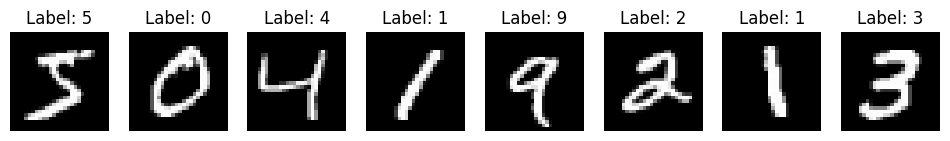

In [3]:
#explore data
print("Classs distribution:\n", pd.Series(y).value_counts().sort_index())

#Visualise a few samples:
fig, axes = plt.subplots(1, 8, figsize=(12,3))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(28,28), cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.show()

In [4]:
#scale data:
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

In [6]:
#train test split
X_train, X_test, y_train, y_test= train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:",  X_train.shape)
print("Test size:", X_test.shape)

Train size: (800, 784)
Test size: (200, 784)


In [8]:
#training SVM using linear kernel and measuring time:

start_time= time.time()

svm_linear= SVC(kernel="linear")
svm_linear.fit(X_train, y_train)

linear_train_time = time.time() - start_time

y_pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)

print(f"Linear Kernel -> Accuracy: {acc_linear:.4f}, Training Time: {linear_train_time:.4f} sec")


Linear Kernel -> Accuracy: 0.8900, Training Time: 0.1035 sec


In [9]:
#Training  SVM with RBF Kernel
start_time = time.time()

svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train, y_train)

rbf_train_time = time.time() - start_time

y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"RBF Kernel -> Accuracy: {acc_rbf:.4f}, Training Time: {rbf_train_time:.4f} sec")

RBF Kernel -> Accuracy: 0.9050, Training Time: 0.3013 sec


In [10]:
#compare linear vs RBF
comparison = pd.DataFrame({
    "Kernel": ["Linear", "RBF"],
    "Accuracy": [acc_linear, acc_rbf],
    "Training Time (sec)": [linear_train_time, rbf_train_time]
})

comparison

,Kernel,Accuracy,Training Time (sec)
0,Linear,0.890,0.103501
1,RBF,0.905,0.301282


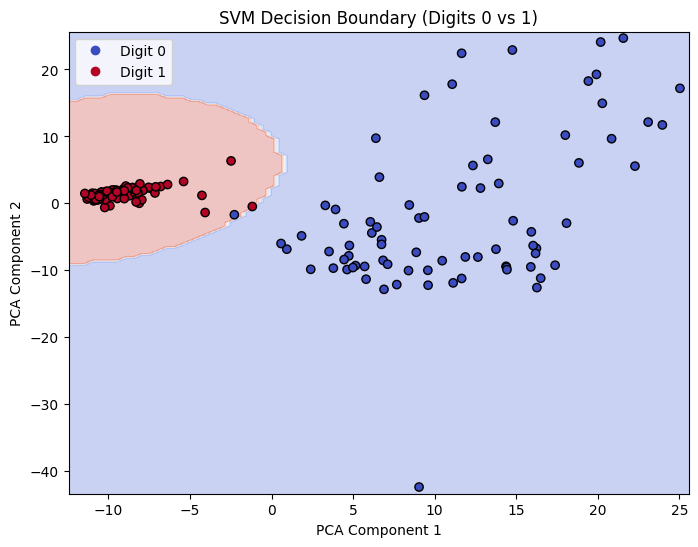

In [14]:
#decision boundary visualisation:
# Picking 2 digit classes for a clean binary problem, e.g. 0 vs 1

mask = (y_train == 0) | (y_train == 1)
X_binary = X_train[mask]     #keeps only the rows where the mask is True.
y_binary = y_train[mask]

# Reduce to 2D using PCA - purely for visualization, since we can't plot 784 dimensions
pca = PCA(n_components=2)
X_binary_2d = pca.fit_transform(X_binary)

# Train SVM on the 2D-reduced data specifically for plotting the boundary
svm_2d = SVC(kernel="rbf")
svm_2d.fit(X_binary_2d, y_binary)

# Create a mesh grid to plot the decision boundary
x_min, x_max = X_binary_2d[:,0].min()-1, X_binary_2d[:,0].max()+1
y_min, y_max = X_binary_2d[:,1].min()-1, X_binary_2d[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
scatter = plt.scatter(X_binary_2d[:,0], X_binary_2d[:,1], c=y_binary, cmap="coolwarm", edgecolors="k")
plt.legend(handles=scatter.legend_elements()[0], labels=["Digit 0", "Digit 1"])
plt.title("SVM Decision Boundary (Digits 0 vs 1)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Samples: 100 -> Training Time: 0.0096 sec
Samples: 300 -> Training Time: 0.0374 sec
Samples: 500 -> Training Time: 0.0702 sec
Samples: 800 -> Training Time: 0.1724 sec
Samples: 1000 -> Training Time: 0.2919 sec


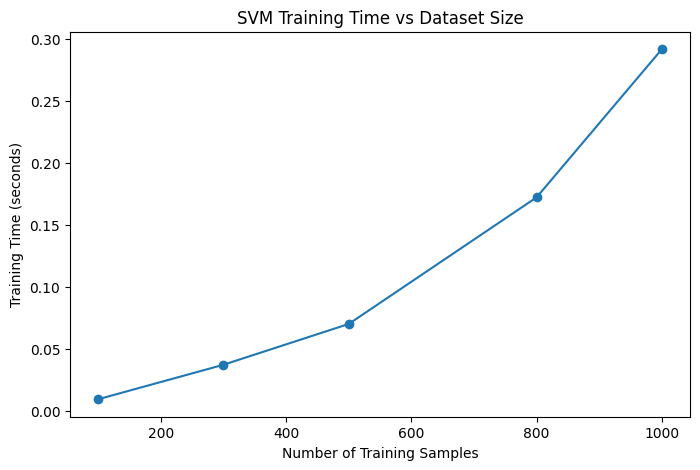

In [12]:
# Testing how training time grows as we increase the number of samples
sample_sizes = [100, 300, 500, 800, 1000]
times_recorded = []

for size in sample_sizes:
    X_subset = X_scaled[:size]
    y_subset = y[:size]

    start = time.time()
    svm_temp = SVC(kernel="rbf")
    svm_temp.fit(X_subset, y_subset)
    elapsed = time.time() - start

    times_recorded.append(elapsed)
    print(f"Samples: {size} -> Training Time: {elapsed:.4f} sec")

plt.figure(figsize=(8,5))
plt.plot(sample_sizes, times_recorded, marker="o")
plt.xlabel("Number of Training Samples")
plt.ylabel("Training Time (seconds)")
plt.title("SVM Training Time vs Dataset Size")
plt.show()